In [2]:
import pandas as pd

In [3]:
products=pd.read_csv("products.csv")
prod_sales=pd.read_csv("prodsales.csv")
print(products)
print(prod_sales)

   product_id   product     category  price
0           1    Laptop  Electronics    800
1           2     Mouse  Electronics     20
2           3     Chair    Furniture    120
3           4  Notebook   Stationery      5
4           5       Pen   Stationery      2
   product_id  quantity
0           1         2
1           2         5
2           3         1
3           4        10
4           5        20


In [4]:
df=pd.merge(products,prod_sales,on="product_id")
df["revenue"]=df["price"]*df["quantity"]
df

,product_id,product,category,price,quantity,revenue
0,1,Laptop,Electronics,800,2,1600
1,2,Mouse,Electronics,20,5,100
2,3,Chair,Furniture,120,1,120
3,4,Notebook,Stationery,5,10,50
4,5,Pen,Stationery,2,20,40


Basic Analysis

In [31]:
t_rev=df["revenue"].sum()
print(f"The total revenue is {t_rev}")
h_rev_idx=df["revenue"].idxmax()
h_rev_prod=df.loc[h_rev_idx,"product"]
print(f"{h_rev_prod} is the highest revenue product")

The total revenue is 1910
Laptop is the highest revenue product


Revenue by category

In [7]:
rev_by_cat=df.groupby("category")["revenue"].sum()
rev_by_cat

category
Electronics    1700
Furniture       120
Stationery       90
Name: revenue, dtype: int64

Pivot table

In [9]:
pivot_table=pd.pivot_table(
    df,
    values="revenue",
    index="category",
    aggfunc="sum"
)
pivot_table

,revenue
category,
Electronics,1700
Furniture,120
Stationery,90


Visualization

<Axes: xlabel='category'>

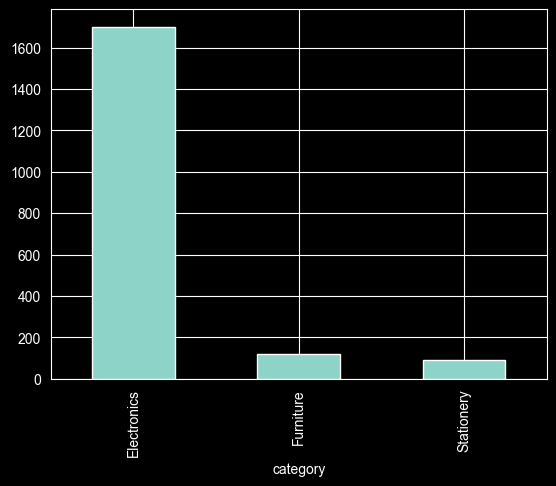

In [10]:
rev_by_cat.plot(kind="bar")


Product that sold most units

product_id             5
product              Pen
category      Stationery
price                  2
quantity              20
revenue               40
Name: 4, dtype: object
Pen sold most units:20


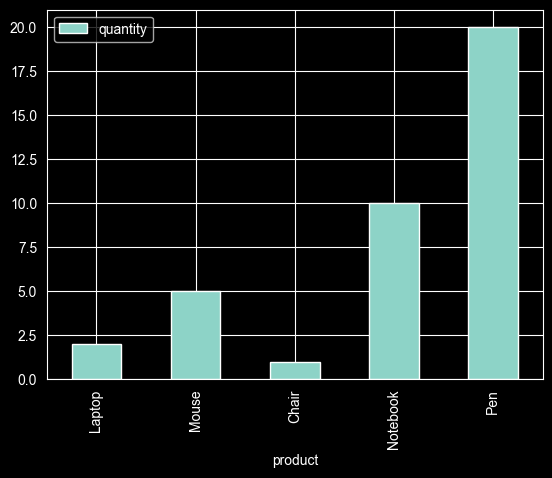

In [34]:
prod_quantity=df.loc[df["quantity"].idxmax()]
print(prod_quantity)
df.plot(x="product",y="quantity",kind="bar")
print(f"{prod_quantity["product"]} sold most units:{prod_quantity["quantity"]}")


Which product generated highest revenue?

<Axes: xlabel='product'>

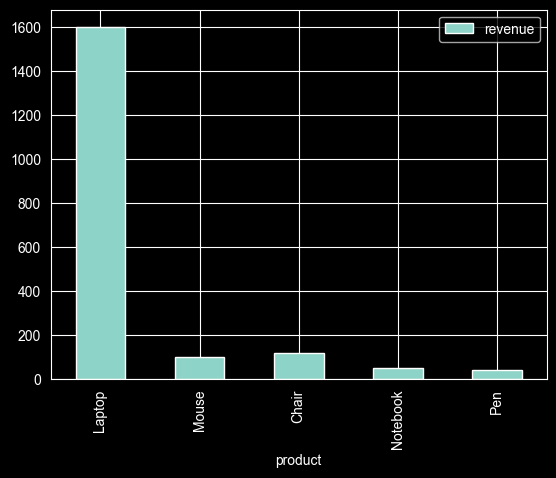

In [36]:
df.plot(y="revenue",x="product",kind="bar")

Laptop generated highest revenue